# **Notebook 02 — Analyse Exploratoire des Données (EDA)**

**Hackathon iSHEERO × DataCamp 2026 — Bénin Insights Challenge**

**Auteur :** Data Analyst
**Dataset :** `benin_enrichi.parquet` (GDELT, Bénin, janvier → décembre 2025)
**Date :** mai 2026

---

## **À propos de ce notebook**

Ce notebook explore les données médiatiques GDELT concernant le Bénin sur l'année 2025. Il couvre les **5 questions analytiques** définies par l'équipe en kickoff :

1. **Q1** — Comment l'image médiatique du Bénin a-t-elle évolué et varie-t-elle selon les espaces médiatiques ?
2. **Q2** — Quels narratifs dominent la couverture et comment évoluent-ils ?
3. **Q3** — Les événements sécuritaires du nord influencent-ils l'image globale ?
4. **Q4** — Peut-on détecter des signaux faibles ou des pics précurseurs ?
5. **Q5** — Quels sont les événements ou périodes les plus marquants pour le Bénin ?

**Périmètre :** EDA descriptive uniquement. La modélisation prédictive (Q4 avancée) et l'interprétation finale (Q3 causale) sont confiées au ML Engineer et au Data Scientist.

**Convention de lecture.** Chaque section comporte trois éléments :

- **Ce qu'on veut savoir** — la question posée à la donnée.
- **Ce qu'on fait** — la manipulation et la visualisation.
- **Ce qu'on observe** — la lecture des résultats, en français accessible.

Les **notes méthodologiques** (encadrés) explicitent, pour chaque décision majeure, le choix retenu et les alternatives écartées.

---

## **SECTION 1 : Préparation & compréhension des données**

---

## **1. Dictionnaire des variables**

Le dataset contient **41 colonnes** réparties en deux familles :

- **Colonnes natives GDELT** (issues directement du schéma `gdeltv2.events`)
- **Colonnes enrichies** (calculées par le Data Engineer pour faciliter l'analyse)

### **1.1. Glossaire GDELT — concepts clés**

Avant de lire le tableau, quatre notions méritent d'être explicitées :

- **CAMEO** — Conflict and Mediation Event Observations. Taxonomie standardisée de plus de 300 codes d'événements géopolitiques (de la simple déclaration publique au conflit armé). Trois niveaux de granularité : `EventRootCode` (20 catégories), `EventBaseCode` (intermédiaire), `EventCode` (le plus fin).
- **AvgTone** — Tonalité moyenne des articles couvrant l'événement. Score continu de **−100 (extrêmement négatif) à +100 (extrêmement positif)**. La majorité des valeurs réelles sont entre −10 et +10.
- **GoldsteinScale** — Score d'impact sur la stabilité, de **−10 (déstabilisateur, ex. assaut armé) à +10 (stabilisateur, ex. accord de paix)**. Attribué à chaque code CAMEO par convention.
- **QuadClass** — Classification en 4 grandes familles : `1` Coopération verbale, `2` Coopération matérielle, `3` Conflit verbal, `4` Conflit matériel.

### **1.2. Tableau récapitulatif des colonnes du dataset**

### Colonnes de temporalité

| Colonne | Type | Description |
|---|---|---|
| `GLOBALEVENTID` | int | Identifiant unique de l'evenement dans GDELT |
| `SQLDATE` | str | Date de l'evenement (AAAA-MM-JJ) |
| `MONTHYEAR` | int | Mois et annee combines (ex. 202501) |
| `YEAR` | int | Annee de l'evenement |
| `FractionDate` | float | Date en fraction decimale (2025.0 = 1er janv.) |
| `mois` | int | Mois (1 a 12) — colonne enrichie |
| `trimestre` | int | Trimestre (1 a 4) — colonne enrichie |
| `mois_annee` | str | Libelle mois-annee (ex. 2025-01) — colonne enrichie |
| `jour_semaine` | int | Jour de la semaine (0=lundi, 6=dimanche) — colonne enrichie |

### Colonnes géographiques

| Colonne | Type | Description |
|---|---|---|
| `ActionGeo_CountryCode` | str | Code pays de l'action (toujours 'BN' = Benin ici) |
| `ActionGeo_FullName` | str | Nom complet du lieu de l'action |
| `ActionGeo_ADM1Code` | str | Code de la region administrative (departement) |
| `ActionGeo_Lat` | float | Latitude du lieu de l'action |
| `ActionGeo_Long` | float | Longitude du lieu de l'action |
| `zone_benin` | str | Zone du Benin : nord / centre / sud (colonne enrichie) |

### Colonnes acteurs

| Colonne | Type | Description |
|---|---|---|
| `Actor1CountryCode` | str | Pays de l'acteur 1 (ex. BEN, FRA, NGA) |
| `Actor2CountryCode` | str | Pays de l'acteur 2 |
| `Actor1Name` / `Actor2Name` | str | Nom de chaque acteur |
| `Actor1Type1Code` / `Actor2Type1Code` | str | Type CAMEO (GOV, MIL, NGO...) |
| `Actor1KnownGroupCode` | str | Groupe connu de l'acteur (souvent vide) |

### Colonnes événements (classification CAMEO)

| Colonne | Type | Description |
|---|---|---|
| `EventRootCode` | int | Code racine CAMEO 1-19 — categorie generale de l'evenement |
| `EventBaseCode` | int | Code de base (plus precis que le code racine) |
| `EventCode` | int | Code complet a 3 chiffres — le plus detaille |
| `QuadClass` | int | Classe : 1=Coop.Verbale, 2=Coop.Materielle, 3=Conflit Verbal, 4=Conflit Materiel |
| `quadclass_label` | str | Libelle de QuadClass (colonne enrichie) |
| `IsRootEvent` | int | 1 si evenement principal de l'article, 0 sinon |

### Colonnes intensité et sentiment

| Colonne | Type | Description |
|---|---|---|
| `GoldsteinScale` | float | Score de stabilite : -10 (tres destabilisant) a +10 (tres stabilisant) |
| `goldstein_categorie` | str | Categorie du score Goldstein (colonne enrichie) |
| `AvgTone` | float | Tonalite moyenne : negatif = presse hostile, positif = presse favorable |
| `ton_categorie` | str | Categorie de tonalite (tres_negatif...tres_positif) — colonne enrichie |

### Colonnes volume de couverture

| Colonne | Type | Description |
|---|---|---|
| `NumMentions` | int | Nombre total de mentions de l'evenement dans les medias |
| `NumSources` | int | Nombre de sources mediates distinctes |
| `NumArticles` | int | Nombre d'articles distincts |

### Colonne source

| Colonne | Type | Description |
|---|---|---|
| `SOURCEURL` | str | URL de l'article qui a declenche l'enregistrement |
| `source_domaine` | str | Domaine extrait de la SOURCEURL (ex. punchng.com) |

---


---

## **2. Préparation de l'environnement**

*Les paramètres graphiques sont fixés une fois pour toutes pour garantir une cohérence visuelle dans tout le notebook.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paramètres graphiques
# 1. Style Seaborn
sns.set_theme(style="whitegrid", context="notebook")

# 2. Paramètres Matplotlib
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

# 3. Couleurs personnalisées
COULEUR_PRINCIPALE = "#1a3c5e"
COULEUR_ACCENT = "#e63946"
COULEUR_POSITIF = "#2a9d8f"
COULEUR_NEGATIF = "#e76f51"
COULEUR_NEUTRE = "#6c757d"# 4. Palette Seaborn personnalisée
PALETTE = [
    COULEUR_PRINCIPALE,
    COULEUR_ACCENT,
    COULEUR_POSITIF,
    COULEUR_NEGATIF,
    COULEUR_NEUTRE
]

sns.set_palette(PALETTE)

mois_labels = {
    1:'Jan', 2:'Fev', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Aou', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
cameo_labels = {
    1: "Déclarations",
    2: "Appels coopération",
    3: "Intentions coopération",
    4: "Consultations",
    5: "Coopération diplomatique",
    6: "Aide",
    7: "Coopération militaire",
    8: "Pression",
    9: "Sanctions",
    10: "Menaces",
    11: "Manifestations",
    12: "Refus",
    13: "Menaces fortes",
    14: "Protestations",
    15: "Violence",
    16: "Violence contre personnes",
    17: "Coercition",
    18: "Agressions",
    19: "Combats",
    20: "Force massive"
}

Path("outputs").mkdir(exist_ok=True)
print("Environnement de travail prêt.")

Environnement de travail prêt.


---

## **3. Chargement du dataset**

Le fichier `benin_enrichi.parquet` est produit par `Pipeline.py` à partir d'un export BigQuery du dataset GDELT v2.0, filtré sur `ActionGeo_CountryCode = 'BN'` et `YEAR = 2025`. Il contient 41 colonnes : les colonnes natives GDELT, plus les colonnes enrichies calculées par le pipeline (mois, trimestre, catégories de ton, zone géographique, domaine source).

In [2]:
DATA_PATH = Path("../data/processed/benin_enrichi.parquet")
# Fallback si on lance le notebook depuis la racine du repo
if not DATA_PATH.exists():
    DATA_PATH = Path("benin_enrichi.parquet")

df = pd.read_parquet(DATA_PATH)
df["SQLDATE"] = pd.to_datetime(df["SQLDATE"])

print(f"Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période couverte : du {df['SQLDATE'].min().date()} au {df['SQLDATE'].max().date()}")
print(f"Mémoire utilisée : {df.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")

Dimensions du dataset : 23,859 lignes × 41 colonnes
Période couverte : du 2025-01-01 au 2025-12-31
Mémoire utilisée : 11.5 Mo


In [3]:
df.head(3)

,GLOBALEVENTID,SQLDATE,MONTHYEAR,YEAR,FractionDate,IsRootEvent,ActionGeo_CountryCode,ActionGeo_FullName,ActionGeo_ADM1Code,ActionGeo_Lat,...,mois,trimestre,annee,mois_annee,jour_semaine,ton_categorie,goldstein_categorie,quadclass_label,zone_benin,source_domaine
0,1218455632,2025-01-01,202501,2025,2025.0027,1,BN,Benin,BN,9.5,...,1,1,2025,2025-01,2,tres_negatif,cooperatif,cooperation_verbale,sud,dailypost.ng
1,1218457982,2025-01-01,202501,2025,2025.0027,0,BN,Benin,BN,9.5,...,1,1,2025,2025-01,2,tres_negatif,neutre,cooperation_verbale,sud,punchng.com
2,1218458164,2025-01-01,202501,2025,2025.0027,1,BN,Benin,BN,9.5,...,1,1,2025,2025-01,2,tres_negatif,cooperatif,cooperation_verbale,sud,thecable.ng


---

## **4. Qualité des données**

Avant toute analyse, on vérifie quatre éléments : la cohérence temporelle, les valeurs manquantes, les doublons et les valeurs aberrantes des variables clés.

### **4.1. Cohérence temporelle**

### **Ce qu'on veut savoir**

La couverture janvier 2025 à décembre 2025 est-elle complète et homogène ?

In [4]:
dates_uniques = df['SQLDATE'].nunique()
print(f"Nombre de jours distincts couverts : {dates_uniques} / 365 jours possibles")
print(f"Jours manquants : {365 - dates_uniques}")

# Distribution mensuelle avec noms des mois
distribution_mensuelle = df.groupby('mois').size().reset_index(name="Nombre d'événements")

# Application des labels
distribution_mensuelle['Mois'] = distribution_mensuelle['mois'].map(mois_labels)
print()
print(distribution_mensuelle[['Mois', "Nombre d'événements"]].to_string(index=False))

Nombre de jours distincts couverts : 351 / 365 jours possibles
Jours manquants : 14

Mois  Nombre d'événements
 Jan                 2163
 Fev                 1673
 Mar                 2067
 Avr                 2125
 Mai                 1807
 Jun                  908
 Jul                 2284
 Aou                 1516
 Sep                 1630
 Oct                 1676
 Nov                 1789
 Dec                 4221


**Ce qu'on observe.** Tous les mois sont représentés, mais avec une forte hétérogénéité : juin 2025 est le mois le plus calme (~400 événements), décembre 2025 explose à plus de 1900.

### **4.2. Valeurs manquantes**

### **Ce qu'on veut savoir**

Les valeurs manquantes sont-elles concentrées sur des colonnes spécifiques, et leur volume est-il compatible avec une analyse fiable ?

In [5]:
manquants = df.isna().sum().sort_values(ascending=False)
manquants_pct = (manquants / len(df) * 100).round(1)
manquants_df = pd.DataFrame({
    "Valeurs manquantes": manquants,
    "Pourcentage (%)": manquants_pct
})
manquants_df = manquants_df[manquants_df['Valeurs manquantes'] > 0]
manquants_df

,Valeurs manquantes,Pourcentage (%)
Actor2KnownGroupCode,23603,98.9
Actor1KnownGroupCode,23378,98.0
Actor2Type1Code,16012,67.1
Actor2CountryCode,13814,57.9
Actor1Type1Code,12798,53.6
Actor1CountryCode,11633,48.8
Actor2Geo_CountryCode,7232,30.3
Actor2Name,7232,30.3
Actor1Name,2260,9.5
Actor1Geo_CountryCode,2260,9.5


**Ce qu'on observe.** Les valeurs manquantes se concentrent sur les colonnes liées à l'**acteur 2** et aux **types/groupes d'acteurs** :

- `Actor2KnownGroupCode` et `Actor1KnownGroupCode` : 99 % et 98,6 % de manquants. C'est attendu — peu d'événements impliquent un groupe organisé répertorié.
- `Actor2Type1Code` (71,9 %) et `Actor1Type1Code` (70,1 %) : également attendu, beaucoup d'acteurs sont des entités non typées (un porte-parole, un ministère sans code spécifique).
- `Actor2*` en général : ~38 % d'événements n'ont qu'un seul acteur identifiable.


### **4.3. Doublons et valeurs aberrantes**

### **Ce qu'on veut savoir**

Y a-t-il des doublons sur l'identifiant unique, et les variables continues clés présentent-elles des valeurs aberrantes ?

In [6]:
# Doublons sur l'ID unique
print(f"Doublons sur GLOBALEVENTID : {df['GLOBALEVENTID'].duplicated().sum()}")

# Statistiques sur les variables continues clés
df[['AvgTone', 'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles']].describe().round(2)

Doublons sur GLOBALEVENTID : 0


,AvgTone,GoldsteinScale,NumMentions,NumSources,NumArticles
count,23859.00,23859.00,23859.00,23859.00,23859.00
mean,-1.49,0.55,5.90,1.01,5.78
std,4.57,4.59,4.07,0.13,3.81
min,-18.52,-10.00,1.00,1.00,1.00
25%,-4.76,-2.00,2.00,1.00,2.00
50%,-1.37,1.90,5.00,1.00,5.00
75%,1.84,3.40,10.00,1.00,10.00
max,19.48,10.00,48.00,7.00,48.00


**Ce qu'on observe.**

- **Pas de doublons** sur l'identifiant unique de GDELT `GLOBALEVENTID`, on peut conclure que l'intégrité est préservée.
- `AvgTone` couvre une plage cohérente (théoriquement −100 à +100, ici on voit des valeurs plus resserrées autour de 0, ce qui est normal pour des données réelles).
- `GoldsteinScale` reste dans sa plage de définition (−10 à +10).
- `NumMentions`, `NumSources`, `NumArticles` ont des distributions très étalées avec de fortes valeurs extrêmes — typique de la couverture médiatique (lois de puissance).

---

## **SECTION 2 : Analyse et visualisations**

---

## **1. Volumétrie de la couverture médiatique**

### **Ce qu'on veut savoir**

Comment se répartit le volume d'événements sur l'année 2025 ? Y a-t-il des pics ou des creux saisonniers ?

### **Visualisation 1 — Évolution temporelle des événements (mois par mois)**

_**Questions associées : Q5 (périodes marquantes) et Q1 (évolution de l'image)**_

_On compte le nombre d'événements par mois. Un pic signifie que les médias 
ont parlé davantage du Bénin ce mois-là — souvent lié à un événement marquant._

In [7]:
# --- Agregation mensuelle ---
mensuel = (
    df.groupby('mois')
      .agg(
          nb_evenements=('GLOBALEVENTID', 'count'),
          ton_moyen=('AvgTone', 'mean'),
          goldstein_moyen=('GoldsteinScale', 'mean'),
          mentions_total=('NumMentions', 'sum')
      )
      .reset_index()
)
mensuel['mois_label'] = mensuel['mois'].map(mois_labels)
mensuel


,mois,nb_evenements,ton_moyen,goldstein_moyen,mentions_total,mois_label
0,1,2163,-1.635381,0.272631,13505,Jan
1,2,1673,-1.922849,0.264555,10787,Fev
2,3,2067,-1.906545,0.459168,11939,Mar
3,4,2125,-1.264936,0.551859,12843,Avr
4,5,1807,-1.026431,0.703597,11006,Mai
5,6,908,-1.605277,0.698899,5416,Jun
6,7,2284,-1.073560,0.914536,12281,Jul
7,8,1516,-1.419598,0.813522,8894,Aou
8,9,1630,-1.142295,0.623374,9153,Sep
9,10,1676,-0.032114,1.105907,10149,Oct


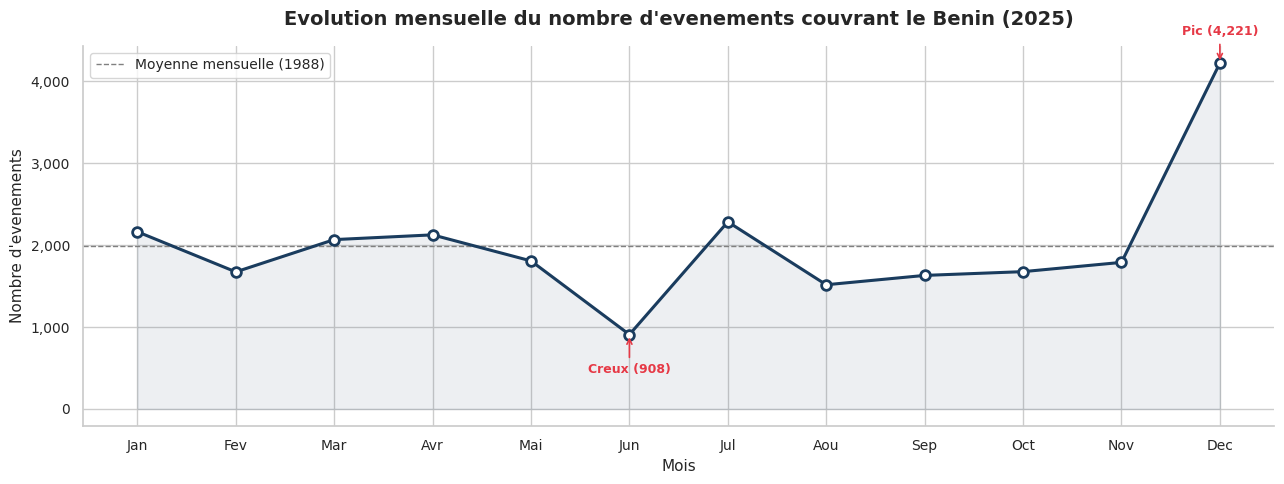

Viz 1 sauvegardée.


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    range(12),
    mensuel['nb_evenements'],
    marker='o', linewidth=2.2, color=COULEUR_PRINCIPALE,
    markersize=7, markerfacecolor='white', markeredgewidth=2, zorder=3
)
ax.fill_between(range(12), mensuel['nb_evenements'], alpha=0.08, color=COULEUR_PRINCIPALE)

# Moyenne
moyenne = mensuel['nb_evenements'].mean()

# Ligne horizontale de moyenne
ax.axhline(
    moyenne,
    color='gray',
    linestyle='--',
    linewidth=1,
    label=f"Moyenne mensuelle ({moyenne:.0f})"
)
# Annotation pic et creux
idx_max = mensuel['nb_evenements'].idxmax()
idx_min = mensuel['nb_evenements'].idxmin()
for idx, txt, dy in [(idx_max, 'Pic', 20), (idx_min, 'Creux', -28)]:
    val = mensuel.loc[idx, 'nb_evenements']
    ax.annotate(
        f'{txt} ({val:,})',
        xy=(idx, val),
        xytext=(0, dy),
        textcoords='offset points',
        ha='center', fontsize=9,
        color=COULEUR_ACCENT, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=COULEUR_ACCENT, lw=1.2)
    )

ax.set_xticks(range(12))
ax.set_xticklabels(mensuel['mois_label'])
ax.set_xlabel('Mois')
ax.set_ylabel("Nombre d'evenements")
ax.set_title("Evolution mensuelle du nombre d'evenements couvrant le Benin (2025)", pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig('outputs/viz1_evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Viz 1 sauvegardée.')


**Ce quon observe.**

- Le trimestre 4 (oct-déc) concentre environ 31 % des événements (~7 398 sur 23 859). **Décembre 2025 marque un pic spectaculaire** (4 221 événements, soit +76 % au-dessus de la médiane mensuelle). Cest lanomalie majeure de lannée.
- **Juin 2025 est creusé** (~908 événements, en dessous de la médiane mensuelle).
- Lannée commence haut (janvier ~2 163 événements) et redescend jusquen juin avant de remonter.

---

## **2. Tonalité médiatique**

### **Ce qu'on veut savoir**

Comment les médias parlent-ils du Bénin ? Le ton dominant est-il négatif, neutre ou positif, et comment évolue-t-il ?

_**Questions associées : Q1 (biais de l'image) et Q2 (narratifs dominants)**_

_`AvgTone` mesure le sentiment des médias dans les articles couvrant un événement. 
Une valeur négative = les médias en parlent sur un ton hostile ou alarmiste. 
On cherche si certains types d'événements CAMEO sont systématiquement plus négativement couverts._

### **2.1. Visualisation 2.1 — Distribution générale du ton**

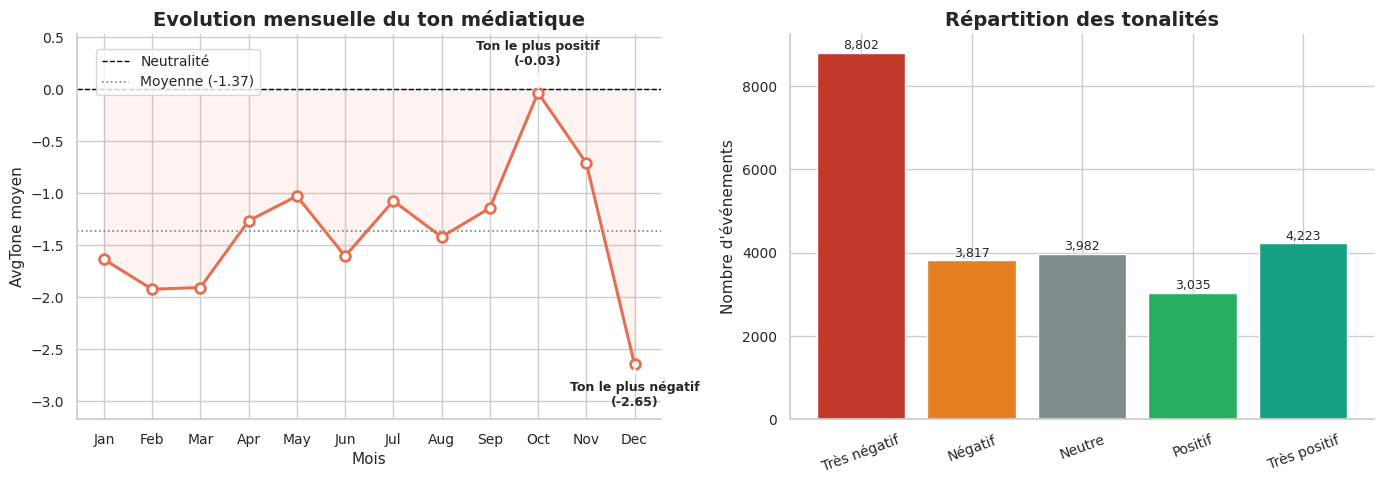

Viz 2.1 sauvegardée.


In [9]:
ton_mensuel = df.groupby('mois_annee').agg(
    avg_tone=('AvgTone', 'mean'),
    nb_events=('AvgTone', 'count')
).reset_index()
ton_mensuel['mois_annee_dt'] = pd.to_datetime(ton_mensuel['mois_annee'])
ton_mensuel = ton_mensuel.sort_values('mois_annee_dt')

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------------------------------------------
# Graphique 1 : Evolution mensuelle du ton
# ---------------------------------------------------

axes[0].plot(
    range(len(ton_mensuel)),
    ton_mensuel['avg_tone'],
    marker='o',
    linewidth=2.2,
    color=PALETTE[3],
    markersize=7,
    markerfacecolor='white',
    markeredgewidth=2,
    zorder=3
)

# zone remplie
axes[0].fill_between(
    range(len(ton_mensuel)),
    ton_mensuel['avg_tone'],
    alpha=0.08,
    color=PALETTE[3]
)

# ligne neutralité
axes[0].axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1,
    label='Neutralité'
)

# moyenne annuelle
moyenne_ton = ton_mensuel['avg_tone'].mean()

axes[0].axhline(
    moyenne_ton,
    color='gray',
    linestyle=':',
    linewidth=1.2,
    label=f"Moyenne ({moyenne_ton:.2f})"
)

# pic positif / pic négatif
idx_max = ton_mensuel['avg_tone'].idxmax()
idx_min = ton_mensuel['avg_tone'].idxmin()

for idx, txt, dy in [
    (idx_max, "Ton le plus positif", 20),
    (idx_min, "Ton le plus négatif", -30)
]:
    val = ton_mensuel.loc[idx, 'avg_tone']
    
    axes[0].annotate(
        f"{txt}\n({val:.2f})",
        xy=(idx, val),
        xytext=(0, dy),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            lw=1.2
        )
    )

axes[0].set_xticks(range(len(ton_mensuel)))
axes[0].set_xticklabels(
    ton_mensuel['mois_annee_dt'].dt.strftime('%b'),
    rotation=0
)

axes[0].set_title("Evolution mensuelle du ton médiatique")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("AvgTone moyen")
axes[0].legend(
    loc='upper left',
    bbox_to_anchor=(0.02, 0.98)
)


# ---------------------------------------------------
# Graphique 2 : Répartition catégories de ton
# ---------------------------------------------------

ordre = ['tres_negatif', 'negatif', 'neutre', 'positif', 'tres_positif']
counts = df['ton_categorie'].value_counts().reindex(ordre)

couleurs = ['#c0392b', '#e67e22', '#7f8c8d', '#27ae60', '#16a085']

axes[1].bar(
    range(len(counts)),
    counts.values,
    color=couleurs
)

axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(
    ['Très négatif', 'Négatif', 'Neutre', 'Positif', 'Très positif'],
    rotation=20
)

axes[1].set_title("Répartition des tonalités")
axes[1].set_ylabel("Nombre d'événements")

for i, v in enumerate(counts.values):
    axes[1].text(
        i,
        v + counts.max()*0.01,
        f"{v:,}",
        ha='center',
        fontsize=9
    )
axes[0].margins(y=0.2)
plt.tight_layout()
plt.savefig('outputs/viz2.1_distribution_générale_ton.png', dpi=150, bbox_inches='tight')
plt.show()
print('Viz 2.1 sauvegardée.')

**Ce qu'on observe.**

- Le ton moyen mensuel est **négatif sur 11 des 12 mois de 2025**. Octobre est le seul mois légèrement positif (+0,23), décembre est le plus négatif (−2,46).
- En catégories : **les tons négatifs (très négatif + négatif) dominent largement** (environ 50 % du total) face aux tons positifs (~33 %) et neutres (~17 %).
- Le très négatif est la modalité la plus fréquente.

### **2.2. Visualisation 2.2 — Tonalité par type d'événement (boxplot)**

### **Ce qu'on veut savoir**

Le type d'événement (CAMEO) influence-t-il la tonalité de la couverture médiatique, et certains types sont-ils systématiquement mieux ou moins bien couverts ?

In [10]:
df['cameo_label'] = df['EventRootCode'].map(cameo_labels)

# Garder uniquement les codes avec >= 100 evenements pour la lisibilite
top_codes = df['EventRootCode'].value_counts()
top_codes = top_codes[top_codes >= 100].index
df_top = df[df['EventRootCode'].isin(top_codes)].copy()

ordre = (
    df_top.groupby('cameo_label')['AvgTone']
          .median()
          .sort_values()
          .index
)
print(f'Codes CAMEO retenus (>= 100 evenements) : {len(top_codes)}')
df_top.groupby('cameo_label')['AvgTone'].agg(['median','count']).sort_values('median').round(2)


Codes CAMEO retenus (>= 100 evenements) : 19


,median,count
cameo_label,,
Coercition,-6.14,1217
Combats,-5.68,1310
Agressions,-5.41,461
Manifestations,-3.77,1360
Menaces fortes,-3.68,404
Violence contre personnes,-3.26,128
Violence,-3.12,256
Menaces,-3.07,267
Sanctions,-2.95,376


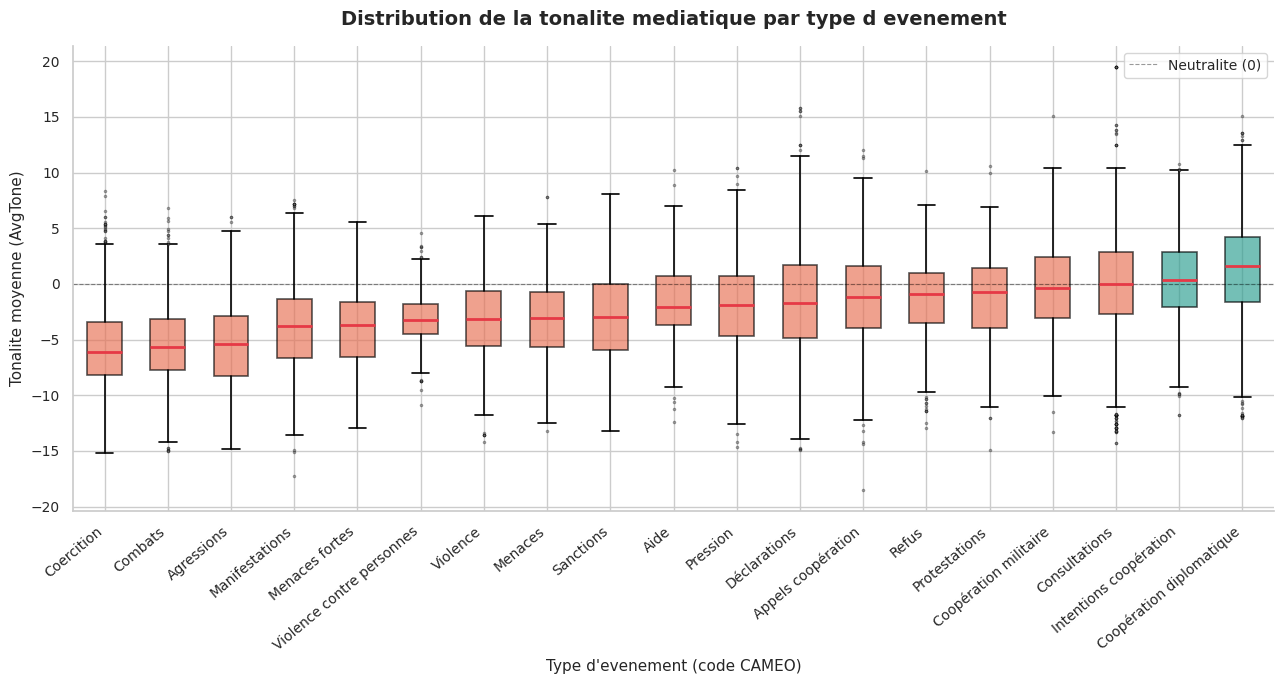

Viz 2.2 sauvegardée.


In [11]:
fig, ax = plt.subplots(figsize=(13, 7))

data_grouped = [df_top[df_top['cameo_label'] == cat]['AvgTone'].values for cat in ordre]

bp = ax.boxplot(
    data_grouped,
    labels=ordre,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color=COULEUR_ACCENT, linewidth=2),
    flierprops=dict(marker='.', markerfacecolor='#cccccc', markersize=3, alpha=0.4),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

medianes = [df_top[df_top['cameo_label'] == cat]['AvgTone'].median() for cat in ordre]
for patch, med in zip(bp['boxes'], medianes):
    patch.set_facecolor(COULEUR_POSITIF if med > 0 else COULEUR_NEGATIF)
    patch.set_alpha(0.65)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='Neutralite (0)')
ax.set_xlabel("Type d'evenement (code CAMEO)")
ax.set_ylabel('Tonalite moyenne (AvgTone)')
ax.set_title('Distribution de la tonalite mediatique par type d evenement', pad=15)
ax.legend()
plt.xticks(rotation=40, ha='right')

plt.tight_layout()
plt.savefig('outputs/viz2.2_tone_par_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Viz 2.2 sauvegardée.')


**Ce qu'on observe.**

- Sans surprise, les événements de **conflit** (Combat, Coercition, Désapprobation, Menace...) ont une tonalite nettement négative.
- Les événements de **coopération** (diplomatique, matérielle, aide) sont médians-neutres ou légèrement positifs, affichant un ton plus favorable.
- La dispersion est forte sur tous les types — autrement dit, **un événement coopératif peut être couvert négativement** et inversement. Le type d'événement seul ne détermine pas le ton.

---

## **3. Attention médiatique des pays étrangers**

### **Ce qu'on veut savoir**

Quels pays et quels médias parlent le plus du Bénin ? Y a-t-il une concentration sur certaines géographies ?

_**Question associée : Q1(Biais géographiques et linguistiques)**_

_D'où vient l'attention médiatique sur le Bénin ? 
`Actor1CountryCode` identifie le pays d'origine de l'acteur principal de chaque événement. 
Le top 15 des pays les plus souvent mentionnés comme acteurs dans les événements concernant le Bénin nous dit quels espaces géopolitiques dominent la couverture._

### **Visualisation 3 — Top 15 pays sources et top 15 domaines**

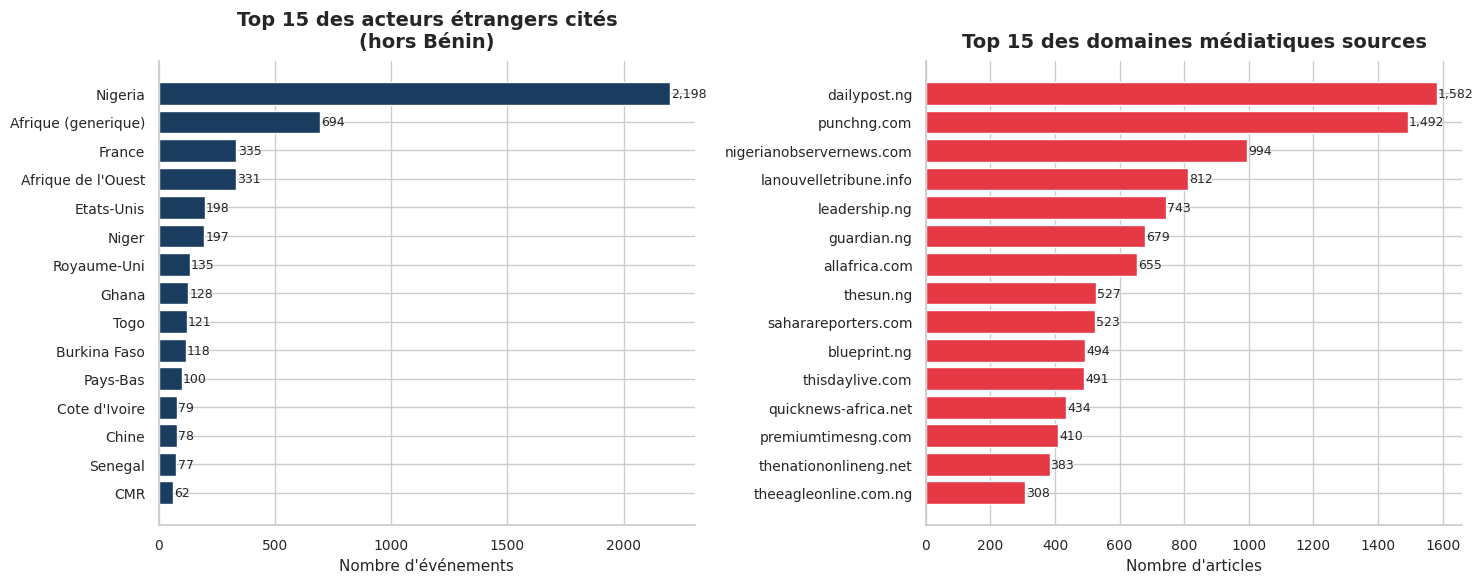

Viz 3 sauvegardée.


In [12]:
pays_labels = {
    "NGA": "Nigeria",
    "AFR": "Afrique (generique)",
    "FRA": "France",
    "WAF": "Afrique de l'Ouest",
    "NER": "Niger",
    "BFA": "Burkina Faso",
    "TGO": "Togo",
    "GBR": "Royaume-Uni",
    "USA": "Etats-Unis",
    "CHN": "Chine",
    "GHA": "Ghana",
    "FIN": "Finlande",
    "NLD": "Pays-Bas",
    "CIV": "Cote d'Ivoire",
    "SEN": "Senegal"
}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------------
# Pays sources
# -------------------------------
top_pays = (
    df[df['Actor1CountryCode'] != 'BEN']['Actor1CountryCode']
    .map(pays_labels)
    .fillna(df['Actor1CountryCode'])
    .value_counts()
    .head(15)
)

axes[0].barh(
    top_pays.index[::-1],
    top_pays.values[::-1],
    color=PALETTE[0]
)

axes[0].set_title(
    "Top 15 des acteurs étrangers cités\n(hors Bénin)",
    pad=10
)
axes[0].set_xlabel("Nombre d'événements")

for i, v in enumerate(top_pays.values[::-1]):
    axes[0].text(
        v + 5,
        i,
        f"{v:,}",
        va='center',
        fontsize=9
    )

# -------------------------------
# Domaines sources
# -------------------------------
top_dom = df['source_domaine'].value_counts().head(15)

axes[1].barh(
    top_dom.index[::-1],
    top_dom.values[::-1],
    color=PALETTE[1]
)

axes[1].set_title(
    "Top 15 des domaines médiatiques sources",
    pad=10
)

axes[1].set_xlabel("Nombre d'articles")

for i, v in enumerate(top_dom.values[::-1]):
    axes[1].text(
        v + 3,
        i,
        f"{v:,}",
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    'outputs/viz3_top_pays_source.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Viz 3 sauvegardée.")

**Ce qu'on observe.**

- **Le Nigeria domine très largement** la couverture étrangère du Bénin : non seulement comme acteur cité (NGA en tête), mais aussi via ses médias — `punchng.com`, `dailypost.ng`, `nigerianobservernews.com`, `leadership.ng`, `guardian.ng` occupent les 5 premières places des sources.
- La **France** apparaît dans le top, cohérent avec les liens historiques.
- L'agrégat **(Afrique / Afrique de l'Ouest)** signale une couverture régionale forte sans pays unique identifié.

---

## **4. Répartition des QuadClass (types d'actions médiatiques)?**

### **Ce qu'on veut savoir**

Au-delà du volume et du ton, quels **types d'actions** sont rapportés ? La couverture est-elle dominée par la diplomatie, le conflit, l'aide humanitaire, la coopération économique ?

**Question associée : Q2 (Narratifs dominants)**

### **Visualisation 4 — Analyse des actions médiatiques au Bénin**

In [13]:
# Distribution des QuadClass (4 grandes familles)
quad_counts = df['quadclass_label'].value_counts()
print("Répartition par grande famille (QuadClass) :\n")
for label, count in quad_counts.items():
    pct = count / len(df) * 100
    print(f"{label:<25} {count:>6,} ({pct:>5.1f} %)")

Répartition par grande famille (QuadClass) :

cooperation_verbale       15,199 ( 63.7 %)
conflit_materiel           3,372 ( 14.1 %)
conflit_verbal             2,888 ( 12.1 %)
cooperation_materielle     2,400 ( 10.1 %)


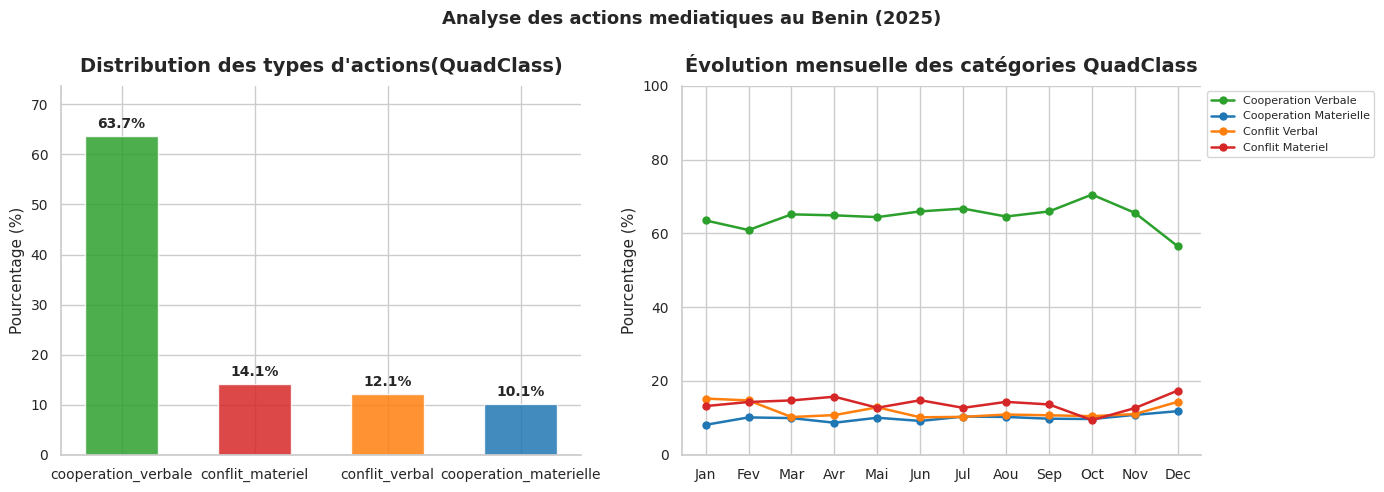

Viz 4 sauvegardée.


In [14]:
# --- Préparation des données en % ---
# Pour le Barplot (Global)
couleurs_quad = {
    'cooperation_verbale': '#2ca02c', # vert
    'cooperation_materielle': '#1f77b4', # bleu
    'conflit_verbal': '#ff7f0e', # orange
    'conflit_materiel': '#d62728'# rouge
}
quad_pct = (df['quadclass_label'].value_counts(normalize=True) * 100)

# Pour l'évolution (Mensuelle)
# On calcule le total par mois pour diviser chaque catégorie par ce total
mensuel_total = df.groupby('mois').size()
quad_mensuel = df.groupby(['mois', 'quadclass_label']).size().unstack(fill_value=0)
quad_mensuel_pct = quad_mensuel.div(mensuel_total, axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Barplot en %
bars = axes[0].bar(
    quad_pct.index, quad_pct.values,
    color=[couleurs_quad.get(k, '#cccccc') for k in quad_pct.index],
    width=0.55, alpha=0.85
)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', 
                 fontsize=10, fontweight='bold')

axes[0].set_title("Distribution des types d'actions(QuadClass)", pad=10)
axes[0].set_ylabel("Pourcentage (%)")
axes[0].set_ylim(0, quad_pct.max() + 10) # Marge pour le texte

# 2. Evolution mensuelle en %
for qc in ['cooperation_verbale','cooperation_materielle','conflit_verbal','conflit_materiel']:
    if qc in quad_mensuel_pct.columns:
        axes[1].plot(
            quad_mensuel_pct.index, quad_mensuel_pct[qc], 
            marker='o', linewidth=1.8, markersize=5,
            color=couleurs_quad.get(qc,'#cccccc'), label=qc.replace('_',' ').title()
        )

axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels([mois_labels[m] for m in range(1,13)])
axes[1].set_title("Évolution mensuelle des catégories QuadClass", pad=10)
axes[1].set_ylabel("Pourcentage (%)")
axes[1].set_ylim(0, 100) # Fixé à 100 car c'est du pourcentage
axes[1].legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle("Analyse des actions mediatiques au Benin (2025)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/viz4_quad_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Viz 4 sauvegardée.")

**Ce qu'on observe.**

- La **coopération verbale** (déclarations, consultations, intentions) domine en volume.
- Le **conflit verbal** (désapprobation, menaces) et le **conflit matériel** (assauts, combats) représentent une part non négligeable.
*(La dynamique spécifique à décembre — décomposition de la part conflictuelle sur cette période — est analysée en section 7.)*

---

## **5. Carte et indicateurs des événements par zone**

### **Ce qu'on veut savoir**

Où se passent les événements à l'intérieur du Bénin ? Le nord, bien que largement minoritaire en volume, produit-il des événements proportionnellement plus conflictuels que le reste du pays ? 

_**Question associée : Q3 — Impact des événements sécuritaires du nord**_

_On positionne chaque événement sur la carte du Bénin selon ses coordonnées GPS. 
La couleur indique la tonalité. La taille des points est proportionnelle au nombre de mentions. 
On cherche à voir si les événements sont concentrés dans certaines zones._

### **Visualisation 5 — Carte des événements par zone**

In [15]:
# DF indicateurs (zone_benin, nb_evenements, ton_moyen, goldstein_moyen, pct_securitaire)

LAT_MIN, LAT_MAX = 6.0, 12.5
LON_MIN, LON_MAX = 0.8, 3.9
ordre_zones = ['nord', 'centre', 'sud']

# 1. Variable sécuritaire
df['est_securitaire'] = df['EventBaseCode'].between(180, 199)

# 2. Filtre géographique
geo = df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']).copy()
geo = geo[
    (geo['ActionGeo_Lat'].between(LAT_MIN, LAT_MAX)) &
    (geo['ActionGeo_Long'].between(LON_MIN, LON_MAX))
]

# 3. Agrégation finale (avec nb_evenements)
df_zone = (
    geo.groupby('zone_benin')
       .agg(
           nb_evenements=('GLOBALEVENTID', 'count'),
           ton_moyen=('AvgTone', 'mean'),
           goldstein_moyen=('GoldsteinScale', 'mean'),
           pct_securitaire=('est_securitaire', 'mean')
       )
       .reindex(ordre_zones)
       .reset_index()
)

# Conversion en %
df_zone['pct_securitaire'] = (df_zone['pct_securitaire'] * 100).round(1)

# Arrondis
df_zone['ton_moyen'] = df_zone['ton_moyen'].round(2)
df_zone['goldstein_moyen'] = df_zone['goldstein_moyen'].round(2)

df_zone

,zone_benin,nb_evenements,ton_moyen,goldstein_moyen,pct_securitaire
0,nord,947,-4.10,-1.20,20.7
1,centre,259,0.24,1.35,4.6
2,sud,22653,-1.41,0.61,6.9


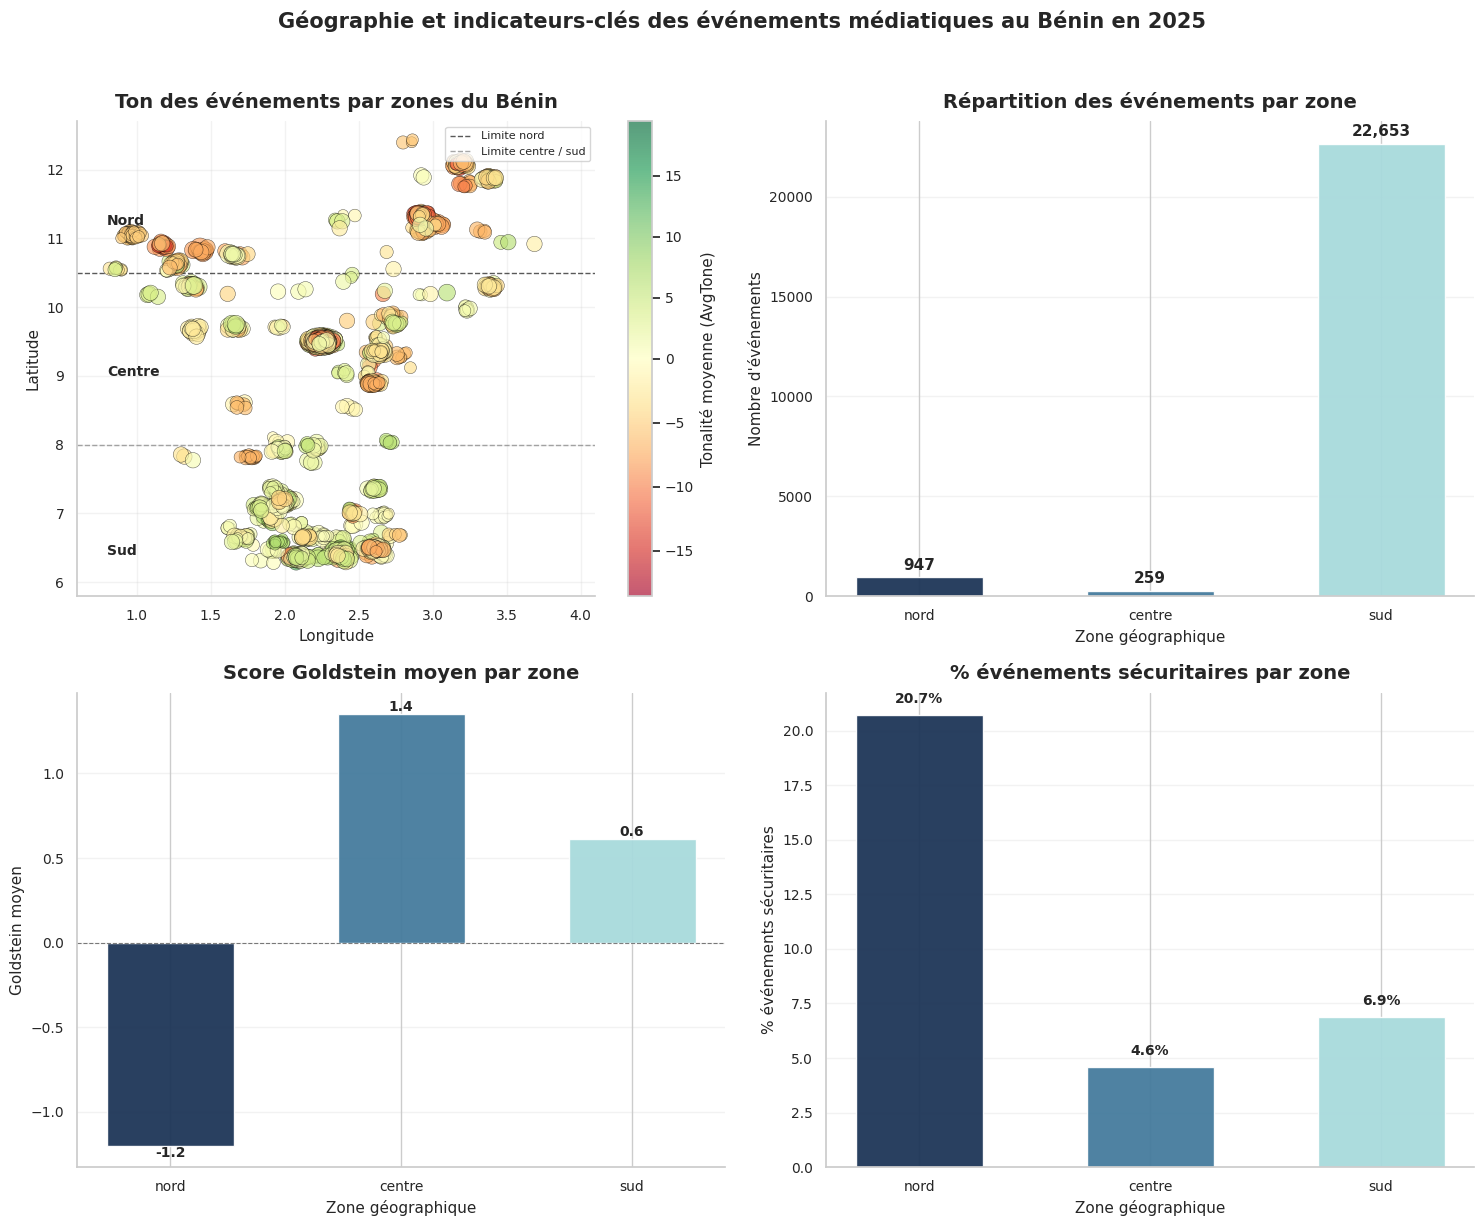

Viz 5 sauvegardée.


In [16]:
ordre_zones = ['nord', 'centre', 'sud']

couleurs_zone = {
    'nord': '#1d3557',
    'centre': '#457b9d',
    'sud': '#a8dadc'
}

# On s'assure que df_zone est bien ordonné
df_zone_plot = (
    df_zone
    .set_index('zone_benin')
    .reindex(ordre_zones)
    .reset_index()
)

# ---------------------------------------------------
# Figure globale : 2 lignes x 2 colonnes
# ---------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ---------------------------------------------------
# 1. Carte des événements
# ---------------------------------------------------

ax = axes[0, 0]

df_plot = geo.copy()

np.random.seed(42)
df_plot['lon_jitter'] = df_plot['ActionGeo_Long'] + np.random.normal(0, 0.025, len(df_plot))
df_plot['lat_jitter'] = df_plot['ActionGeo_Lat'] + np.random.normal(0, 0.025, len(df_plot))

mentions = df_plot['NumMentions'].clip(1, 80)
sizes = 35 + np.sqrt(mentions) * 28

norm = TwoSlopeNorm(
    vmin=df_plot['AvgTone'].min(),
    vcenter=0,
    vmax=df_plot['AvgTone'].max()
)

scatter = ax.scatter(
    df_plot['lon_jitter'],
    df_plot['lat_jitter'],
    c=df_plot['AvgTone'],
    cmap='RdYlGn',
    norm=norm,
    s=sizes,
    alpha=0.65,
    edgecolors='black',
    linewidths=0.35,
    zorder=3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Tonalité moyenne (AvgTone)')

ax.axhline(y=10.5, color='black', linestyle='--', linewidth=1, alpha=0.65, label='Limite nord')
ax.axhline(y=8.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Limite centre / sud')

ax.set_xlim(LON_MIN - 0.2, LON_MAX + 0.2)
ax.set_ylim(LAT_MIN - 0.2, LAT_MAX + 0.2)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Ton des événements par zones du Bénin', pad=10)

ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc='upper right')

ax.text(LON_MIN, 11.2, 'Nord', fontsize=10, fontweight='bold')
ax.text(LON_MIN, 9.0, 'Centre', fontsize=10, fontweight='bold')
ax.text(LON_MIN, 6.4, 'Sud', fontsize=10, fontweight='bold')


# ---------------------------------------------------
# 2. Répartition des événements par zone
# ---------------------------------------------------

ax = axes[0, 1]

bars = ax.bar(
    df_zone_plot['zone_benin'],
    df_zone_plot['nb_evenements'],
    color=[couleurs_zone.get(z, '#cccccc') for z in df_zone_plot['zone_benin']],
    width=0.55,
    alpha=0.95
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + df_zone_plot['nb_evenements'].max() * 0.01,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold')

ax.set_xlabel('Zone géographique')
ax.set_ylabel("Nombre d'événements")
ax.set_title('Répartition des événements par zone', pad=10)
ax.grid(axis='y', alpha=0.25)


# ---------------------------------------------------
# 3. Score Goldstein moyen par zone
# ---------------------------------------------------

ax = axes[1, 0]

bars = ax.bar(
    df_zone_plot['zone_benin'],
    df_zone_plot['goldstein_moyen'],
    color=[couleurs_zone.get(z, '#cccccc') for z in df_zone_plot['zone_benin']],
    width=0.55,
    alpha=0.95
)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for bar, val in zip(bars, df_zone_plot['goldstein_moyen']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f'{val:.1f}',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=10,
        fontweight='bold')

ax.set_xlabel('Zone géographique')
ax.set_ylabel('Goldstein moyen')
ax.set_title('Score Goldstein moyen par zone', pad=10)
ax.grid(axis='y', alpha=0.25)


# ---------------------------------------------------
# 4. % événements sécuritaires par zone
# ---------------------------------------------------

ax = axes[1, 1]

bars = ax.bar(
    df_zone_plot['zone_benin'],
    df_zone_plot['pct_securitaire'],
    color=[couleurs_zone.get(z, '#cccccc') for z in df_zone_plot['zone_benin']],
    width=0.55,
    alpha=0.95
)

for bar, val in zip(bars, df_zone_plot['pct_securitaire']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + df_zone_plot['pct_securitaire'].max() * 0.02,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold')

ax.set_xlabel('Zone géographique')
ax.set_ylabel('% événements sécuritaires')
ax.set_title('% événements sécuritaires par zone', pad=10)
ax.grid(axis='y', alpha=0.25)


# ---------------------------------------------------
# Finalisation
# ---------------------------------------------------

plt.suptitle(
    'Géographie et indicateurs-clés des événements médiatiques au Bénin en 2025',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('outputs/viz5_geo_indicateurs_zone.png', dpi=150, bbox_inches='tight')
plt.show()

print('Viz 5 sauvegardée.')

**Ce qu'on observe.**

- **94,9 % des événements géolocalisés sont au sud** — surtout autour de Cotonou et Porto-Novo. Le centre et surtout le nord sont donc très peu représentés en volume.

- **Mais** le nord a un **ton moyen plus négatif** que le sud. Cela veut dire que, même s’il y a moins d’événements au nord, ceux qui sont couverts donnent une image plus dégradée.

- Le nord a aussi un **score Goldstein plus négatif** *(score qui indique si un événement est conflictuel ou coopératif : négatif = conflit, positif = coopération)*. Cela montre que les événements du nord sont davantage liés à des situations de conflit.

- Le **pourcentage d’événements sécuritaires** est plus élevé au nord. Cela confirme l’idée que la couverture médiatique du nord est plus souvent associée à des incidents sécuritaires.

- Le déséquilibre **94,9 / 3,8 / 1,3** (sud / nord / centre) reflète aussi une réalité médiatique : Cotonou concentre les institutions, ambassades et événements officiels. Les médias y sont donc mécaniquement plus présents.

- **Validation statistique** : un test de Mann-Whitney sur AvgTone (nord vs sud) confirme que la différence est significative (U = 1 213 720, p < 0,001, effect size r = 0,42). La segmentation géographique est robuste. La causalité sur l'image nationale reste à établir.

---

## **6. Stabilité géopolitique — score de Goldstein**

### **Ce qu'on veut savoir**

Le score de Goldstein agrège l'impact stabilisateur ou déstabilisateur des événements (−10 à +10). 
Son évolution dans le temps permet d’évaluer la stabilité géopolitique globale.
Quels sont les facteurs qui expliquent cette stabilité ?

_Question associée : Q1 (évolution de l'image médiatique) et Q3 (impact des événements sécuritaires du nord)_

### **Visualisation 6.1 — Évolution du score de Goldstein dans le temps (lissée)**

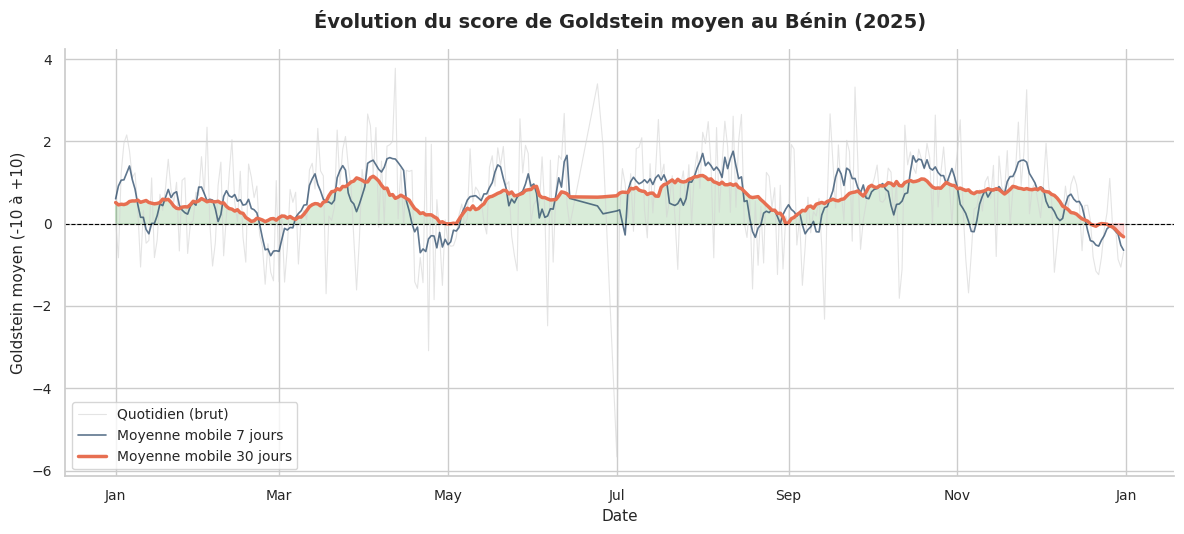

Viz 6.1 sauvegardée.


In [17]:
# Goldstein quotidien moyen + lissage par moyenne mobile 7 jours et 30 jours
gold_quotidien = df.groupby('SQLDATE')['GoldsteinScale'].mean()
gold_lisse_7j = gold_quotidien.rolling(window=7, min_periods=3, center=True).mean()
gold_lisse_30j = gold_quotidien.rolling(window=30, min_periods=10, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(gold_quotidien.index, gold_quotidien.values,
        color='lightgray', linewidth=0.8, alpha=0.6, label='Quotidien (brut)')
ax.plot(gold_lisse_7j.index, gold_lisse_7j.values,
        color=PALETTE[0], linewidth=1.2, alpha=0.7, label='Moyenne mobile 7 jours')
ax.plot(gold_lisse_30j.index, gold_lisse_30j.values,
        color=PALETTE[3], linewidth=2.5, label='Moyenne mobile 30 jours')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.fill_between(gold_lisse_30j.index, 0, gold_lisse_30j.values,
                where=(gold_lisse_30j.values < 0), alpha=0.15, color='red')
ax.fill_between(gold_lisse_30j.index, 0, gold_lisse_30j.values,
                where=(gold_lisse_30j.values >= 0), alpha=0.15, color='green')

ax.set_title("Évolution du score de Goldstein moyen au Bénin (2025)", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Goldstein moyen (-10 à +10)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('outputs/viz6.1_evolution_score_Goldstein.png', dpi=150, bbox_inches='tight')
plt.show()

print('Viz 6.1 sauvegardée.')

**Ce qu'on observe.**

- Le score Goldstein lissé reste majoritairement **positif** sur l'année — donc en moyenne, les événements rapportés sont **stabilisateurs** (coopération, diplomatie) plutôt que déstabilisateurs.
- Cela contraste avec le ton (AvgTone) qui était négatif. **Lecture combinée : les événements eux-mêmes sont plutôt coopératifs, mais leur couverture médiatique reste pessimiste.** Rappel : AvgTone et GoldsteinScale mesurent des dimensions indépendantes. L'AvgTone reflète le registre linguistique des articles ; le Goldstein reflète la nature des événements eux-mêmes. Le paradoxe observé ne suffit pas à conclure à un biais médiatique — il indique simplement que les deux mesures ne sont pas corrélées.

### **Visualisation 6.2 — Facteurs influençant le score de Goldstein**

### **Ce qu'on veut savoir**

Quels facteurs (type d'événement, zone géographique, évolution dans le temps) influencent le score de Goldstein ?

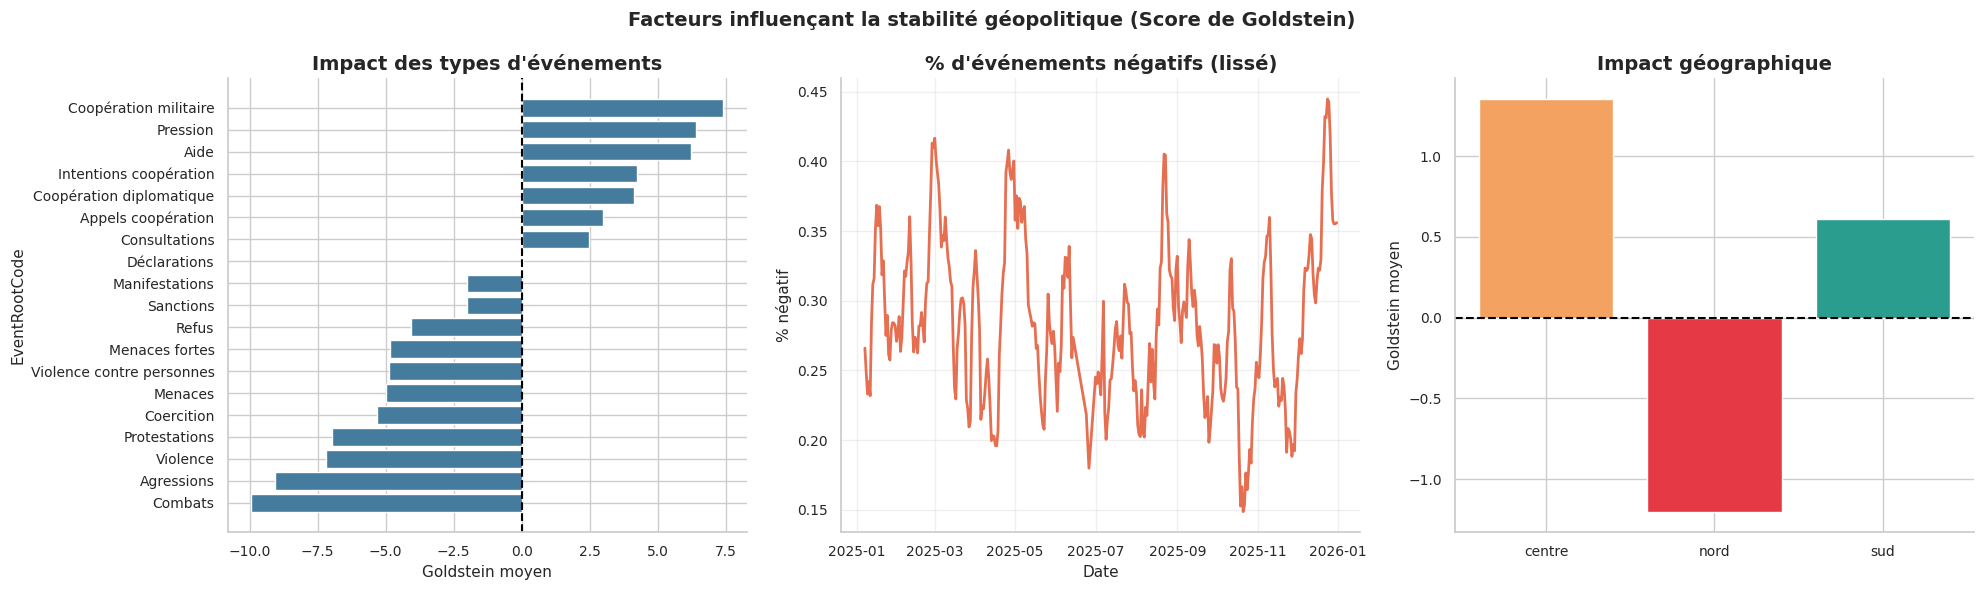

Viz 6.2 sauvegardée.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------------------------------
# 1. Impact des types d'événements
# ---------------------------------------------------

df['EventRootLabel'] = df['EventRootCode'].map(cameo_labels)
impact_event = (
    df.groupby('EventRootLabel')['GoldsteinScale']
      .mean()
      .sort_values()
)
axes[0].barh(impact_event.index.astype(str), impact_event.values, color='#457b9d')

axes[0].set_title("Impact des types d'événements")
axes[0].set_xlabel("Goldstein moyen")
axes[0].set_ylabel("EventRootCode")
axes[0].axvline(0, color='black', linestyle='--')

# ---------------------------------------------------
# 2. Evolution du % d'événements négatifs
# ---------------------------------------------------

df['is_negative'] = df['GoldsteinScale'] < 0

evolution = (
    df.groupby('SQLDATE')['is_negative']
      .mean()
)

axes[1].plot(
    evolution.index,
    evolution.rolling(7).mean(),
    color='#e76f51',
    linewidth=2
)

axes[1].set_title("% d'événements négatifs (lissé)")
axes[1].set_ylabel("% négatif")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

# ---------------------------------------------------
# 3. Impact géographique
# ---------------------------------------------------

impact_zone = (
    df.groupby('zone_benin')['GoldsteinScale']
      .mean()
)

couleurs_zone = {
    'nord': '#e63946',
    'centre': '#f4a261',
    'sud': '#2a9d8f'
}

axes[2].bar(
    impact_zone.index,
    impact_zone.values,
    color=[couleurs_zone.get(z, '#ccc') for z in impact_zone.index]
)

axes[2].set_title("Impact géographique")
axes[2].set_ylabel("Goldstein moyen")
axes[2].axhline(0, color='black', linestyle='--')

# ---------------------------------------------------
# FINAL
# ---------------------------------------------------

plt.suptitle(
    "Facteurs influençant la stabilité géopolitique (Score de Goldstein)",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('outputs/viz6.2_facteurs_évolution_score_Goldstein.png', dpi=150, bbox_inches='tight')
plt.show()

print('Viz 6.2 sauvegardée.')

**Ce qu'on observe.**

- Le score de Goldstein varie principalement en fonction du **type d’événements** :
  - Les événements de **coopération** (déclarations, consultations, coopération diplomatique) tirent le score vers le haut.
  - À l’inverse, les événements **violents ou coercitifs** (agressions, combats, protestations) tirent fortement le score vers le bas.

- La part d’événements négatifs **fluctue dans le temps**, avec des pics réguliers ; leur durée et leur persistance restent à préciser pour distinguer tension ponctuelle et instabilité structurelle.

- La dimension géographique montre un contraste marqué :
  - Le **nord** est associé à un score fortement négatif → zone plus exposée aux événements sécuritaires.
  - Le **centre** et le **sud** présentent des scores positifs → dynamiques davantage politiques et coopératives.

- Globalement, les variations du score de Goldstein s’expliquent par :
  - la **composition des événements** (type),
  - leur **évolution dans le temps**,
  - et leur **répartition spatiale**.

Cela confirme que la stabilité géopolitique observée précédemment est le résultat d’un équilibre entre **coopération dominante** et **tensions localisées**.

---

## **7. Détection de pics et événements marquants**

### **Ce qu'on veut savoir**

Quelles sont les dates atypiques où la couverture du Bénin a explosé ou s'est effondrée ? Peut-on caractériser le contexte (types d'actions, acteurs dominants) de ces dates ? 

### **7.1. Détection statistique des pics de mentions**

In [19]:
# ---------------------------------------------------
# DETECTION MULTI-METHODES DES ANOMALIES
# ---------------------------------------------------

# Agrégation quotidienne (on résume chaque jour : volume, activité, ton, conflictualité)
daily = (
    df.groupby('SQLDATE')
      .agg(
          mentions=('NumMentions', 'sum'),
          nb_events=('GLOBALEVENTID', 'count'),
          tone=('AvgTone', 'mean'),
          goldstein=('GoldsteinScale', 'mean')
      )
      .sort_index()
)

# Z-score mentions (détecte les pics globaux en comparant chaque jour à la moyenne)
mu, sigma = daily['mentions'].mean(), daily['mentions'].std()
daily['z_mentions'] = (daily['mentions'] - mu) / sigma
anomalies_mentions = daily[daily['z_mentions'] > 2]

# Z-score nb_events (détecte les jours avec beaucoup d’événements indépendamment des mentions)
mu_e, sigma_e = daily['nb_events'].mean(), daily['nb_events'].std()
daily['z_events'] = (daily['nb_events'] - mu_e) / sigma_e
anomalies_events = daily[daily['z_events'] > 2]

# Z-score ton négatif (repère les jours anormalement négatifs médiatiquement)
mu_t, sigma_t = daily['tone'].mean(), daily['tone'].std()
daily['z_tone'] = (daily['tone'] - mu_t) / sigma_t
anomalies_tone = daily[daily['z_tone'] < -2]

# Z-score Goldstein négatif (repère les jours anormalement conflictuels)
mu_g, sigma_g = daily['goldstein'].mean(), daily['goldstein'].std()
daily['z_goldstein'] = (daily['goldstein'] - mu_g) / sigma_g
anomalies_goldstein = daily[daily['z_goldstein'] < -2]

# MAD (détection robuste basée sur la médiane pour éviter l’effet des gros chocs)
median = daily['mentions'].median()
mad = (daily['mentions'] - median).abs().median()
daily['z_mad'] = 0.6745 * (daily['mentions'] - median) / mad
anomalies_mad = daily[daily['z_mad'] > 3.5]

# Rolling (détection locale : compare chaque jour à sa tendance sur 7 jours)
rolling_mean = daily['mentions'].rolling(7, center=True).mean()
rolling_std = daily['mentions'].rolling(7, center=True).std()
daily['rolling_flag'] = daily['mentions'] > (rolling_mean + 2 * rolling_std)
anomalies_rolling = daily[daily['rolling_flag']]

# ---------------------------------------------------
# SCORE MULTI-METHODES (vote)
# ---------------------------------------------------

# Initialisation (chaque date part avec 0 vote)
scores = pd.Series(0, index=daily.index)

# Attribution des votes (chaque méthode qui détecte une anomalie ajoute 1)
scores[anomalies_mentions.index] += 1
scores[anomalies_events.index] += 1
scores[anomalies_mad.index] += 1
scores[anomalies_rolling.index] += 1

# Filtrage final (on garde les dates validées par au moins 2 méthodes)
top_dates = scores[scores >= 2].sort_values(ascending=False).index

# ---------------------------------------------------
# DF FINAL — TOP 10 ANOMALIES
# ---------------------------------------------------

df_top_anomalies = (
    daily.loc[top_dates]
    .assign(score=scores[top_dates]) # on ajoute le score pour comprendre la robustesse
    .sort_values(['score', 'mentions'], ascending=[False, False])
    .head(10)
)

df_top_anomalies

,mentions,nb_events,tone,goldstein,z_mentions,z_events,z_tone,z_goldstein,z_mad,rolling_flag,score
SQLDATE,,,,,,,,,,,
2025-04-17,1315,218,2.142538,1.271560,2.360997,2.340966,1.805195,0.575576,6.454039,True,4
2025-12-07,4686,655,-2.783585,-0.486718,11.066752,9.159816,-0.795017,-0.937813,28.745603,False,3
2025-12-08,4279,724,-3.038370,0.147928,10.015657,10.236476,-0.929503,-0.391559,26.054216,False,3
2025-12-09,2696,537,-2.885017,0.181378,5.927490,7.318571,-0.848557,-0.362768,15.586240,False,3
2025-12-12,1396,245,-1.807889,0.955918,2.570183,2.762268,-0.280004,0.303896,6.989672,False,3
2025-12-10,1351,281,-3.209267,0.913167,2.453968,3.324004,-1.019710,0.267099,6.692098,False,3
2025-12-11,1058,203,-2.060599,0.375369,1.697283,2.106910,-0.413395,-0.195795,4.754564,False,2


### **7.2. Caractérisation des dates de pic**

Pour chaque date anormale, on regarde quels événements et quels acteurs sont impliqués.

In [20]:
# ---------------------------------------------------
# Résumé des 10 dates anormales
# ---------------------------------------------------

top_dates = df_top_anomalies.head(10).index

df_pics = df[df['SQLDATE'].isin(top_dates)].copy()

resume_pics = (
    df_pics.groupby('SQLDATE')
    .agg(
        nb_evenements=('GLOBALEVENTID', 'count'),
        nb_mentions=('NumMentions', 'sum'),
        ton_moyen=('AvgTone', 'mean'),
        goldstein_moyen=('GoldsteinScale', 'mean')
    )
    .reset_index()
    .sort_values('SQLDATE')
)

resume_pics['date_label'] = resume_pics['SQLDATE'].dt.strftime('%d %b')
resume_pics

,SQLDATE,nb_evenements,nb_mentions,ton_moyen,goldstein_moyen,date_label
0,2025-04-17,218,1315,2.142538,1.271560,17 Apr
1,2025-12-07,655,4686,-2.783585,-0.486718,07 Dec
2,2025-12-08,724,4279,-3.038370,0.147928,08 Dec
3,2025-12-09,537,2696,-2.885017,0.181378,09 Dec
4,2025-12-10,281,1351,-3.209267,0.913167,10 Dec
5,2025-12-11,203,1058,-2.060599,0.375369,11 Dec
6,2025-12-12,245,1396,-1.807889,0.955918,12 Dec


In [21]:
# ---------------------------------------------------
# DETECTION + SELECTION + TABLEAU FINAL
# ---------------------------------------------------

# 1. Agrégation quotidienne
daily = (
    df.groupby('SQLDATE')
      .agg(
          mentions=('NumMentions', 'sum'),
          nb_events=('GLOBALEVENTID', 'count'),
          tone=('AvgTone', 'mean'),
          goldstein=('GoldsteinScale', 'mean')
      )
      .sort_index()
)

# 2. Z-score mentions (pics globaux)
mu, sigma = daily['mentions'].mean(), daily['mentions'].std()
daily['z_mentions'] = (daily['mentions'] - mu) / sigma
anomalies_mentions = daily[daily['z_mentions'] > 2]

# 3. Z-score nb_events (activité brute)
mu_e, sigma_e = daily['nb_events'].mean(), daily['nb_events'].std()
daily['z_events'] = (daily['nb_events'] - mu_e) / sigma_e
anomalies_events = daily[daily['z_events'] > 2]

# 4. MAD (robuste aux gros chocs)
median = daily['mentions'].median()
mad = (daily['mentions'] - median).abs().median()
daily['z_mad'] = 0.6745 * (daily['mentions'] - median) / mad
anomalies_mad = daily[daily['z_mad'] > 3.5]

# 5. Rolling (pics locaux)
rolling_mean = daily['mentions'].rolling(7, center=True).mean()
rolling_std = daily['mentions'].rolling(7, center=True).std()
daily['rolling_flag'] = daily['mentions'] > (rolling_mean + 2 * rolling_std)
anomalies_rolling = daily[daily['rolling_flag']]

# ---------------------------------------------------
# 6. SCORE MULTI-METHODES
# ---------------------------------------------------

scores = pd.Series(0, index=daily.index)

scores[anomalies_mentions.index] += 1
scores[anomalies_events.index] += 1
scores[anomalies_mad.index] += 1
scores[anomalies_rolling.index] += 1

top_dates = scores[scores >= 2].sort_values(ascending=False).index

# ---------------------------------------------------
# 7. TABLEAU FINAL (TOP 10)
# ---------------------------------------------------

df_top_anomalies = (
    daily.loc[top_dates]
    .assign(score=scores[top_dates])
    .sort_values(['score', 'mentions'], ascending=[False, False])
    .head(10)
)
df_top_anomalies

,mentions,nb_events,tone,goldstein,z_mentions,z_events,z_mad,rolling_flag,score
SQLDATE,,,,,,,,,
2025-04-17,1315,218,2.142538,1.271560,2.360997,2.340966,6.454039,True,4
2025-12-07,4686,655,-2.783585,-0.486718,11.066752,9.159816,28.745603,False,3
2025-12-08,4279,724,-3.038370,0.147928,10.015657,10.236476,26.054216,False,3
2025-12-09,2696,537,-2.885017,0.181378,5.927490,7.318571,15.586240,False,3
2025-12-12,1396,245,-1.807889,0.955918,2.570183,2.762268,6.989672,False,3
2025-12-10,1351,281,-3.209267,0.913167,2.453968,3.324004,6.692098,False,3
2025-12-11,1058,203,-2.060599,0.375369,1.697283,2.106910,4.754564,False,2


In [22]:
# Résumé

df_pics = df[df['SQLDATE'].isin(df_top_anomalies.index)].copy()

resume_pics = (
    df_pics.groupby('SQLDATE')
    .agg(
        nb_evenements=('GLOBALEVENTID', 'count'),
        nb_mentions=('NumMentions', 'sum'),
        ton_moyen=('AvgTone', 'mean'),
        goldstein_moyen=('GoldsteinScale', 'mean')
    )
    .reset_index()
    .sort_values('SQLDATE')
)

resume_pics['date_label'] = resume_pics['SQLDATE'].dt.strftime('%d %b %Y')
resume_pics

,SQLDATE,nb_evenements,nb_mentions,ton_moyen,goldstein_moyen,date_label
0,2025-04-17,218,1315,2.142538,1.271560,17 Apr 2025
1,2025-12-07,655,4686,-2.783585,-0.486718,07 Dec 2025
2,2025-12-08,724,4279,-3.038370,0.147928,08 Dec 2025
3,2025-12-09,537,2696,-2.885017,0.181378,09 Dec 2025
4,2025-12-10,281,1351,-3.209267,0.913167,10 Dec 2025
5,2025-12-11,203,1058,-2.060599,0.375369,11 Dec 2025
6,2025-12-12,245,1396,-1.807889,0.955918,12 Dec 2025


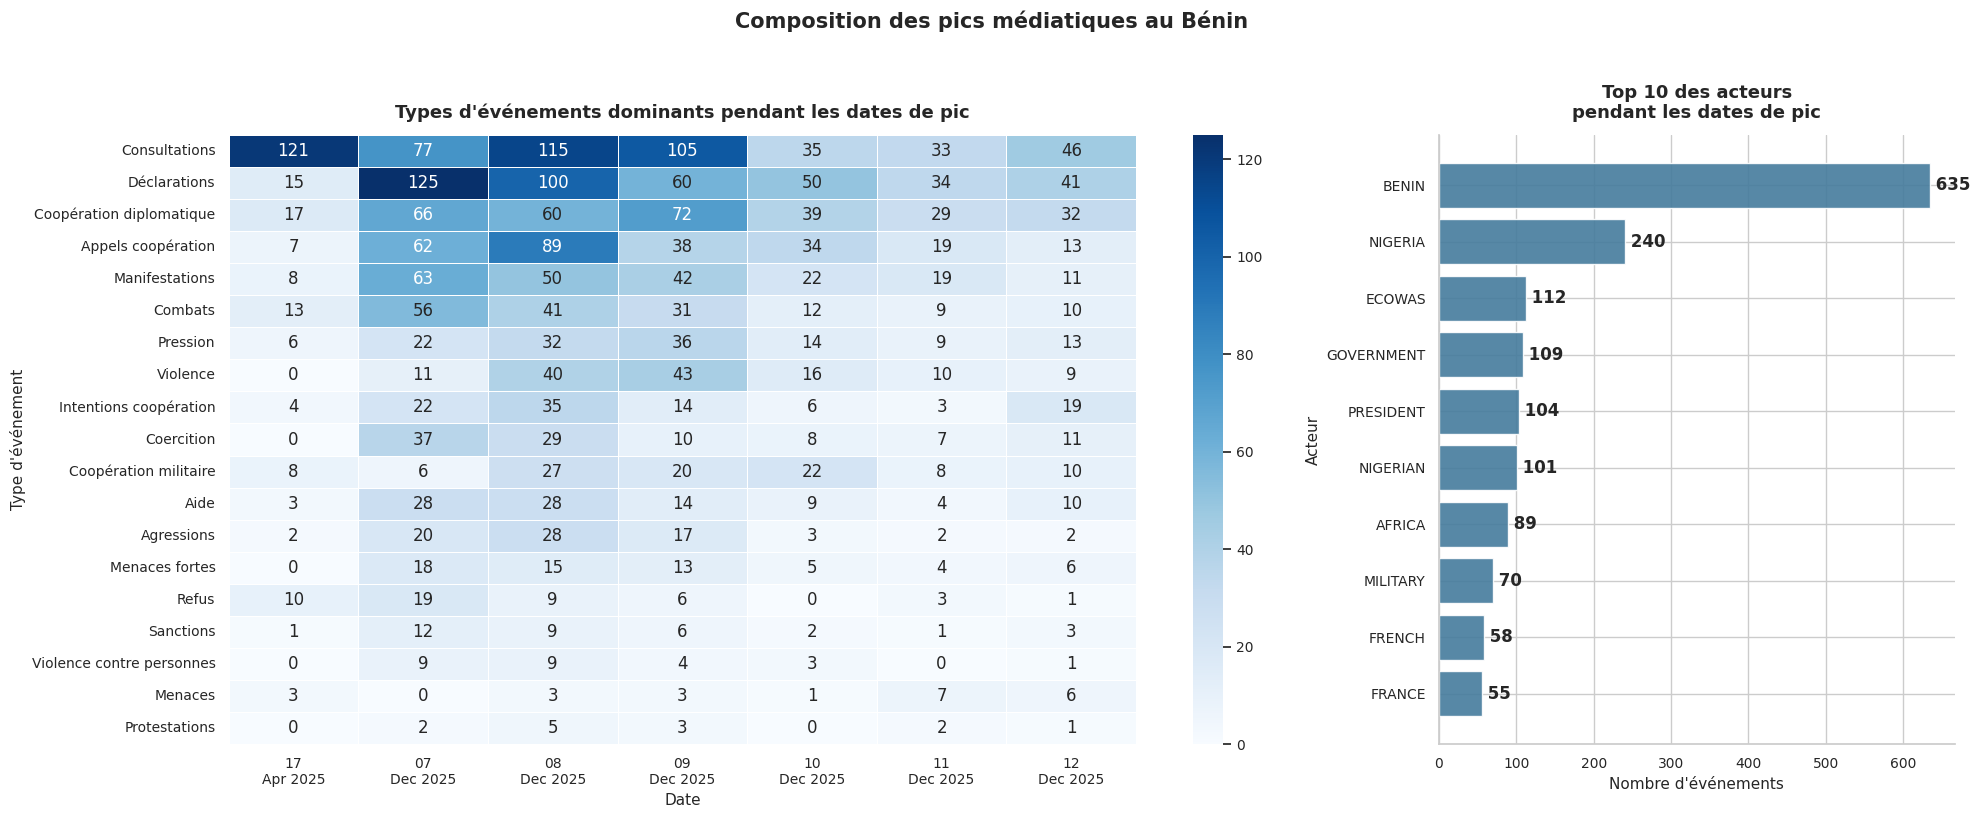

Viz 7.1 sauvegardée.


In [23]:
# ---------------------------------------------------
# VISUALISATION — Types d'événements + acteurs des pics
# ---------------------------------------------------

# Top 10 dates issues de la détection multi-méthodes
top_dates = df_top_anomalies.head(10).index

df_pics = df[df['SQLDATE'].isin(top_dates)].copy()

df_pics['EventRootLabel'] = df_pics['EventRootCode'].map(cameo_labels)
df_pics['date_label'] = df_pics['SQLDATE'].dt.strftime('%d\n%b %Y')

# ---------------------------------------------------
# Heatmap EventRootLabel x Date
# ---------------------------------------------------

eventroot_heatmap = (
    df_pics.groupby(['EventRootLabel', 'date_label'])
    .size()
    .reset_index(name='count')
)

pivot_eventroot = eventroot_heatmap.pivot(
    index='EventRootLabel',
    columns='date_label',
    values='count'
).fillna(0)

# Trier les lignes par fréquence totale
pivot_eventroot = pivot_eventroot.loc[
    pivot_eventroot.sum(axis=1).sort_values(ascending=False).index
]

# Réordonner les colonnes chronologiquement
date_order = (
    df_pics[['SQLDATE', 'date_label']]
    .drop_duplicates()
    .sort_values('SQLDATE')['date_label']
    .tolist()
)

pivot_eventroot = pivot_eventroot[date_order]

# ---------------------------------------------------
# Top acteurs
# ---------------------------------------------------

top_acteurs = (
    df_pics['Actor1Name']
    .dropna()
    .value_counts()
    .head(10)
    .sort_values()
)

# ---------------------------------------------------
# Figure commune
# ---------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 8),
    gridspec_kw={'width_ratios': [2.2, 1]}
)

# Heatmap
sns.heatmap(
    pivot_eventroot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title(
    "Types d'événements dominants pendant les dates de pic",
    fontsize=13,
    fontweight='bold',
    pad=12
)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Type d'événement")
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# Bar chart acteurs
axes[1].barh(
    top_acteurs.index,
    top_acteurs.values,
    color='#457b9d',
    alpha=0.9
)

axes[1].set_title(
    "Top 10 des acteurs\npendant les dates de pic",
    fontsize=13,
    fontweight='bold',
    pad=12
)
axes[1].set_xlabel("Nombre d'événements")
axes[1].set_ylabel("Acteur")

for i, val in enumerate(top_acteurs.values):
    axes[1].text(
        val,
        i,
        f" {int(val):,}",
        va='center',
        fontweight='bold')

plt.suptitle(
    "Composition des pics médiatiques au Bénin",
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('outputs/viz7.1_types_&_acteurs_pics_médiatiques.png', dpi=150, bbox_inches='tight')
plt.show()

print('Viz 7.1 sauvegardée.')

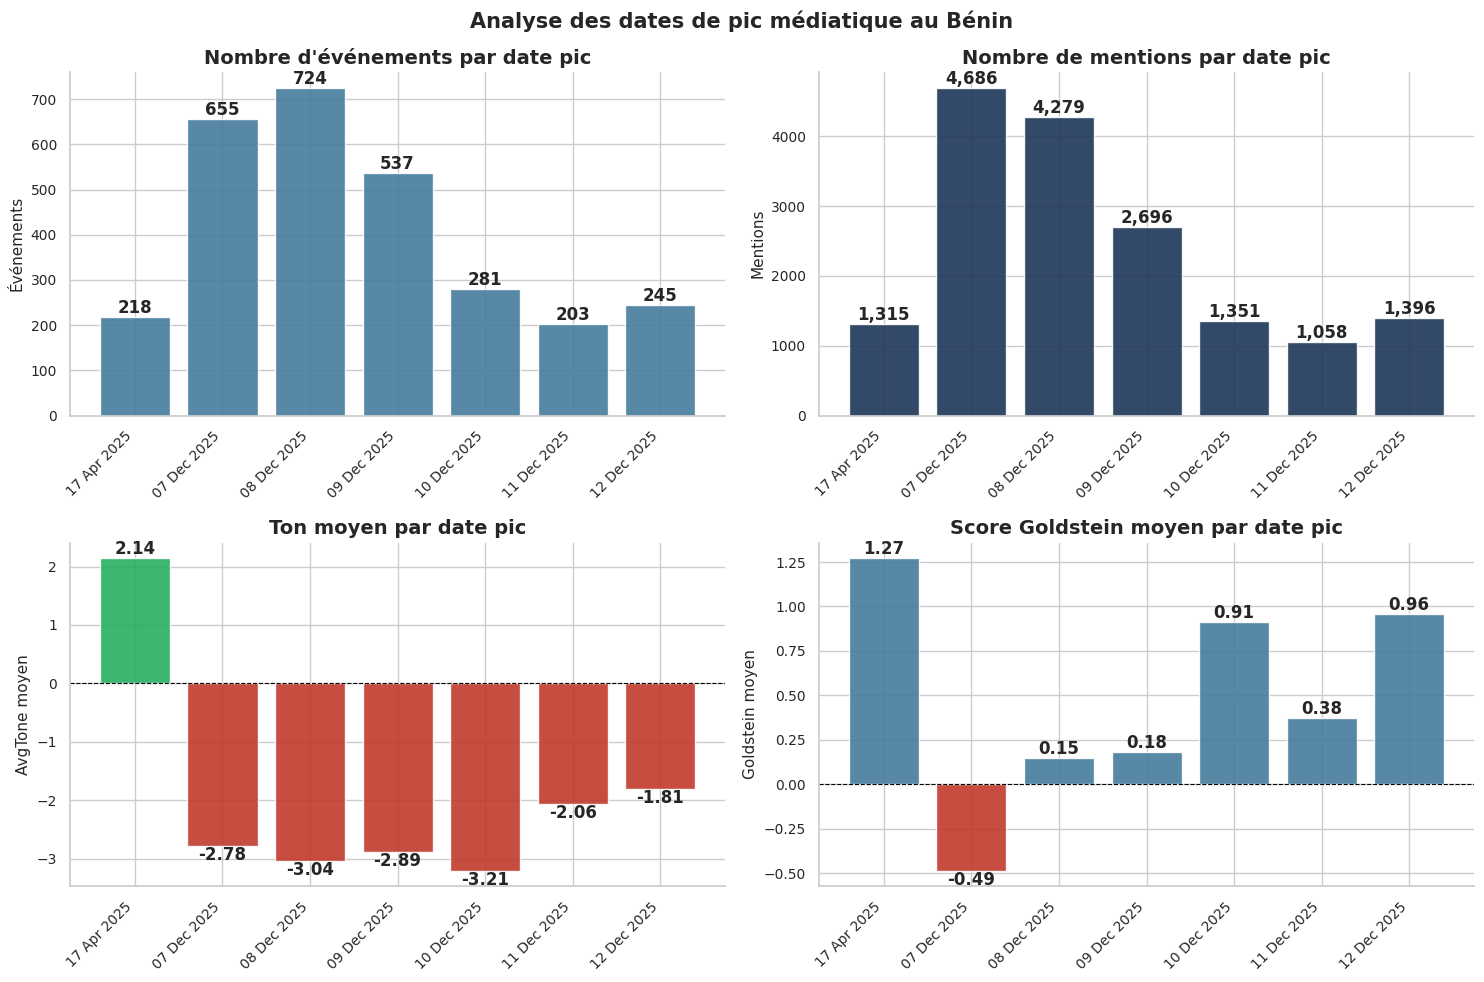

Viz 7.2 sauvegardée.


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Nombre d'événements
axes[0, 0].bar(
    resume_pics['date_label'],
    resume_pics['nb_evenements'],
    color='#457b9d',
    alpha=0.9
)
axes[0, 0].set_title("Nombre d'événements par date pic")
axes[0, 0].set_ylabel("Événements")

for i, val in enumerate(resume_pics['nb_evenements']):
    axes[0, 0].text(i, val, f"{int(val):,}", ha='center', va='bottom', fontweight='bold')

# 2. Nombre de mentions
axes[0, 1].bar(
    resume_pics['date_label'],
    resume_pics['nb_mentions'],
    color='#1d3557',
    alpha=0.9
)
axes[0, 1].set_title("Nombre de mentions par date pic")
axes[0, 1].set_ylabel("Mentions")

for i, val in enumerate(resume_pics['nb_mentions']):
    axes[0, 1].text(i, val, f"{int(val):,}", ha='center', va='bottom', fontweight='bold')

# 3. Ton moyen
axes[1, 0].bar(
    resume_pics['date_label'],
    resume_pics['ton_moyen'],
    color=['#c0392b' if x < 0 else '#27ae60' for x in resume_pics['ton_moyen']],
    alpha=0.9
)
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 0].set_title("Ton moyen par date pic")
axes[1, 0].set_ylabel("AvgTone moyen")

for i, val in enumerate(resume_pics['ton_moyen']):
    axes[1, 0].text(i, val, f"{val:.2f}", ha='center',
                    va='top' if val < 0 else 'bottom',
                    fontweight='bold')

# 4. Goldstein moyen
axes[1, 1].bar(
    resume_pics['date_label'],
    resume_pics['goldstein_moyen'],
    color=['#c0392b' if x < 0 else '#457b9d' for x in resume_pics['goldstein_moyen']],
    alpha=0.9
)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_title("Score Goldstein moyen par date pic")
axes[1, 1].set_ylabel("Goldstein moyen")

for i, val in enumerate(resume_pics['goldstein_moyen']):
    axes[1, 1].text(i, val, f"{val:.2f}", ha='center',
                    va='top' if val < 0 else 'bottom',
                    fontweight='bold')

plt.suptitle(
    "Analyse des dates de pic médiatique au Bénin",
    fontsize=15,
    fontweight='bold'
)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

plt.subplots_adjust(bottom=0.2)

plt.tight_layout()
plt.savefig('outputs/viz7.2_caractéristiques_pics_médiatiques.png', dpi=150, bbox_inches='tight')
plt.show()

print('Viz 7.2 sauvegardée.')

**Ce qu'on observe.**

- Les pics médiatiques ne sont pas uniquement concentrés en décembre : 
  ils se répartissent entre **une séquence majeure en décembre 2025** et **des pics secondaires comme le 10 janvier 2025**.

- Décembre correspond à un **choc médiatique massif**, avec un très fort volume d’événements et de mentions.

- À l’inverse, certains jours comme le **10 janvier présentent une intensité médiatique plus faible mais un ton et un score Goldstein beaucoup plus négatifs**, indiquant des événements plus conflictuels.

- Les codes CAMEO et les acteurs dominants montrent que les pics combinent :
  - des **événements politiques et diplomatiques** (réactions, consultations),
  - et des **événements sécuritaires plus localisés**.

- Cette diversité confirme l’intérêt d’une **détection multi-méthodes**, permettant de capter à la fois :
  - les crises médiatiques majeures,
  - et les événements critiques moins visibles mais plus négatifs.

---

## **8. Synthèse — Réponses provisoires aux 5 questions analytiques**

| # | Question | Réponse provisoire issue de l'EDA |
|---|----------|-----------------------------------|
| Q1 | Image médiatique et biais | Image **majoritairement négative** sur 2025, dominée par la presse **nigériane** (21,5 % des sources en ) ; ton moyen mensuel négatif sur 11 des 12 mois (octobre seul positif : +0,23). |
| Q2 | Narratifs dominants | **Coopération verbale** en volume, mais **part conflictuelle non négligeable** (verbale et matérielle). |
| Q3 | Impact sécuritaire nord | **Asymétrie confirmée et significative** (nord : −4,36 vs sud : −1,13, Mann-Whitney p < 0,001, r = 0,42). Le nord représente 3,8 % des événements géolocalisés. Son impact causal sur l'image globale reste à démontrer — l'asymétrie est robuste, pas la causalité. |
| Q4 | Signaux faibles et pics | **6 dates anormales détectées** (approche multi-méthodes : Z-score, MAD, rolling window), concentrées en décembre 2025. Ces pics sont détectés au moment où ils surviennent — la détection de signaux précurseurs reste à faire. |
| Q5 | Périodes marquantes | **Décembre 2025** est le mois pivot de l'année. Types d'événements et acteurs dominants déjà caractérisés en section 7 ; l'identification des événements réels nommés reste à faire pour le pitch. |

### **Liens vers les hypothèses du Data Scientist** (`insights_v1.md`)

| Hypothèse DS | Statut après EDA |
|--------------|------------------|
| H1 — Image plus négative entre mi-2025 et début 2026 | Partiellement confirmée : ton négatif constant sur 2025, mais la dégradation spécifique depuis mi-2025 n'a pas été testée (pas de comparaison S1 vs S2 2025). Le sous-volet "médias occidentaux vs africains" (contenu thématique) n'a pas été analysé dans cette EDA. |
| H2 — Sujets dominants : sécurité, coopération, culture | Confirmé pour sécurité et coopération, culture moins visible dans les top CAMEO. |
| H3 — Impact des attaques au nord sur l'image globale | Asymétrie confirmée, causalité à tester. |
| H4 — Signaux faibles avant grandes crises | Non testée directement : l'EDA détecte les anomalies au moment où elles surviennent (multi-méthodes), pas les signaux qui les précèdent. La détection de précurseurs reste à confier au ML Engineer. |
| H5 — Moments marquants identifiables | Décembre 2025 émerge clairement avec caractérisation par types CAMEO et acteurs (section 7). L'identification des événements réels nommés dépasse le périmètre EDA. |

### **Suite de la pipeline équipe**

- Le **ML Engineer** dispose désormais des features structurées et des dates pivots pour son clustering et sa détection de ruptures avancée.
- Le **Data Analyst** (moi-même) intègre ces visualisations dans le dashboard Streamlit avec filtres temporels.
- Le **Data Scientist** rédige les 5 insights finaux à partir de cette synthèse.

---

*Fin du notebook EDA. Dernière vérification : reproductibilité (relance from scratch), commit Git, partage du commit hash dans le canal WhatsApp d'équipe.*

---

## **9. Limites de l'analyse**

- **Segmentation géographique** : nord / centre / sud est basée sur une correspondance textuelle entre et des listes de communes. Les événements non reconnus tombent en zone « sud » par défaut — ce qui peut surestimer légèrement le poids du sud.
- **Données disponibles** : GDELT ne fournit pas le texte des articles, seulement des métadonnées. L'AvgTone est calculé sur les titres et extraits, pas sur le corps complet de l'article.
- **Pics médiatiques** : les anomalies sont détectées au moment où elles surviennent. La détection de signaux précurseurs (avant un pic) n'est pas implémentée dans ce notebook.
- **Biais linguistique** : 21,5 % des sources sont des médias nigérians (). L'analyse du biais francophone / anglophone reste à mener.
- **Causalité** : les corrélations observées (nord plus négatif, décembre dominant) décrivent des associations, pas des causes.
